In [1]:
import blpapi

import pdblp
import numpy as np
from xbbg import blp

import matplotlib.pyplot as plt

from datetime import datetime, timedelta
import pandas as pd

import seaborn as sns
import pytz




import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind

In [2]:
def Daily_GetTopCCYs(currency_pairs, years):
    df_ccy = {}
    start_date = (datetime.today() - timedelta(days= years * 356)).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')

    for ticker in currency_pairs:
        data_ccy = blp.bdh(
            tickers=f"{ticker}" ,
            flds=["PX_LAST"],  # Adjust fields as needed
            start_date=start_date,
            end_date=end_date,
            Per="D"  # Daily data
        )
        data_ccy.columns = [ticker]
        df_ccy[ticker] = data_ccy
    df_ccyAll = pd.concat(df_ccy, axis=1)
    df_ccyAll.columns = df_ccyAll.columns.droplevel(0) if isinstance(df_ccyAll.columns, pd.MultiIndex) else df_ccyAll.columns
    df_ccyAll = df_ccyAll.sort_index(ascending=True)


    return df_ccyAll

In [74]:
currency_pairs = ['S0159FC 1M1D BCAL Curncy', 'S0198FC 1M1D BCAL Curncy', 'AUDUSDV1M BGN Curncy', 'NZDUSDV1M BGN Curncy']
years = 10

df = Daily_GetTopCCYs(currency_pairs, years)

df['FwdRate_Spread'] = df['S0159FC 1M1D BCAL Curncy'] - df['S0198FC 1M1D BCAL Curncy']


df['FwdRate_Spread_Pct'] = ((df['AUDUSDV1M BGN Curncy'] - df['NZDUSDV1M BGN Curncy']) / 
                             df['NZDUSDV1M BGN Curncy']) * 100

df['Spread_Change'] = df['FwdRate_Spread'].diff()
df['Spread_Change_Pct'] = df['FwdRate_Spread'].pct_change() * 100

df['AUDUSD_Vol_Change'] = df['AUDUSDV1M BGN Curncy'].diff()
df['NZDUSD_Vol_Change'] = df['NZDUSDV1M BGN Curncy'].diff()

df['Vol_Spread'] = df['AUDUSDV1M BGN Curncy'] - df['NZDUSDV1M BGN Curncy']

df[['S0159FC 1M1D BCAL Curncy', 'S0198FC 1M1D BCAL Curncy', 'FwdRate_Spread', 'Vol_Spread', 'AUDUSDV1M BGN Curncy', 'NZDUSDV1M BGN Curncy']]

C:\Users\ntaylor\AppData\Local\Temp\ipykernel_43660\2100227846.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Spread_Change_Pct'] = df['FwdRate_Spread'].pct_change() * 100


,S0159FC 1M1D BCAL Curncy,S0198FC 1M1D BCAL Curncy,FwdRate_Spread,Vol_Spread,AUDUSDV1M BGN Curncy,NZDUSDV1M BGN Curncy
2016-02-08,1.9626,2.4845,-0.5219,-1.0450,12.8800,13.9250
2016-02-09,1.9511,2.4771,-0.5260,-0.7950,13.3950,14.1900
2016-02-10,1.9399,2.4713,-0.5314,-1.5475,13.1875,14.7350
2016-02-11,1.9399,2.4624,-0.5225,-1.6725,13.8425,15.5150
2016-02-12,1.9571,2.4638,-0.5067,-1.4725,13.2925,14.7650
...,...,...,...,...,...,...
2025-11-03,3.5766,2.3331,1.2435,-0.1900,7.5100,7.7000
2025-11-04,3.5782,2.2936,1.2846,-0.2425,7.8925,8.1350
2025-11-05,3.5798,2.2757,1.3041,-0.3925,7.7150,8.1075
2025-11-06,3.5788,2.2785,1.3003,-0.3100,7.7325,8.0425


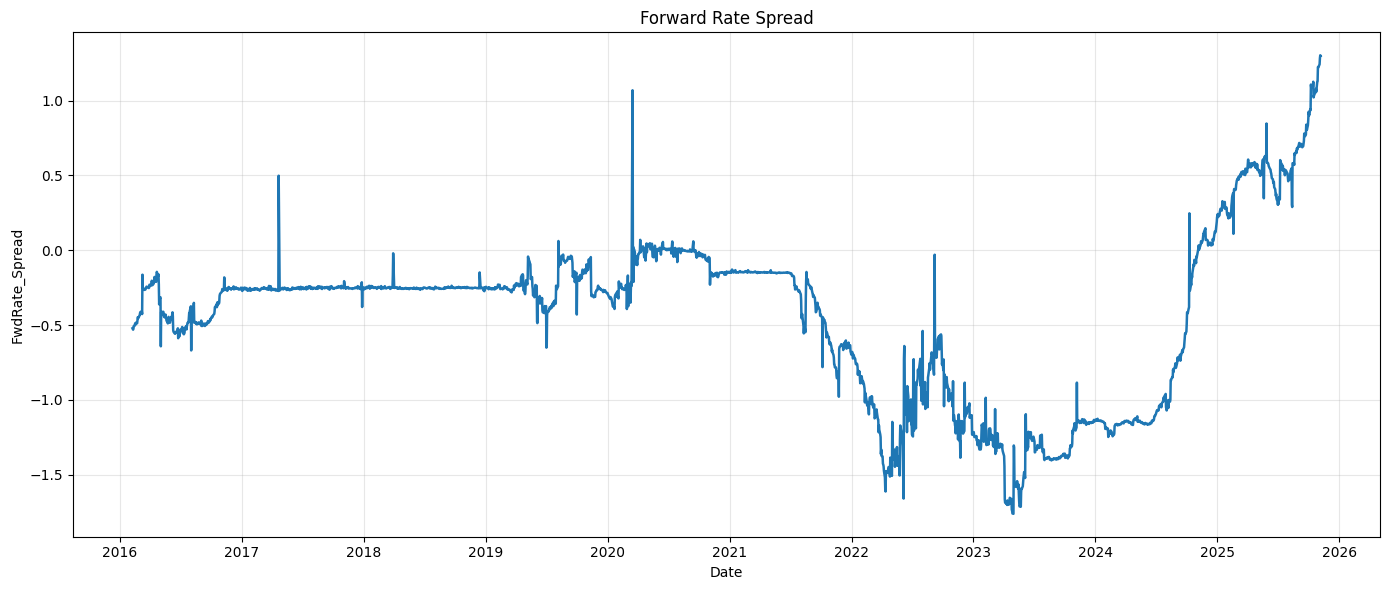

In [10]:
currency_pairs = ['EURUSD Curncy', 'GBPUSD Curncy', 'USDJPY Curncy', 'USDCHF Curncy', 'USDMXN Curncy', 'USDBRL Curncy','SPX Index', 'XAU Curncy', 'BBDXY Index']

years = 5

df = Daily_GetTopCCYs(currency_pairs, years)

C:\Users\ntaylor\AppData\Local\Temp\ipykernel_49920\851557930.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


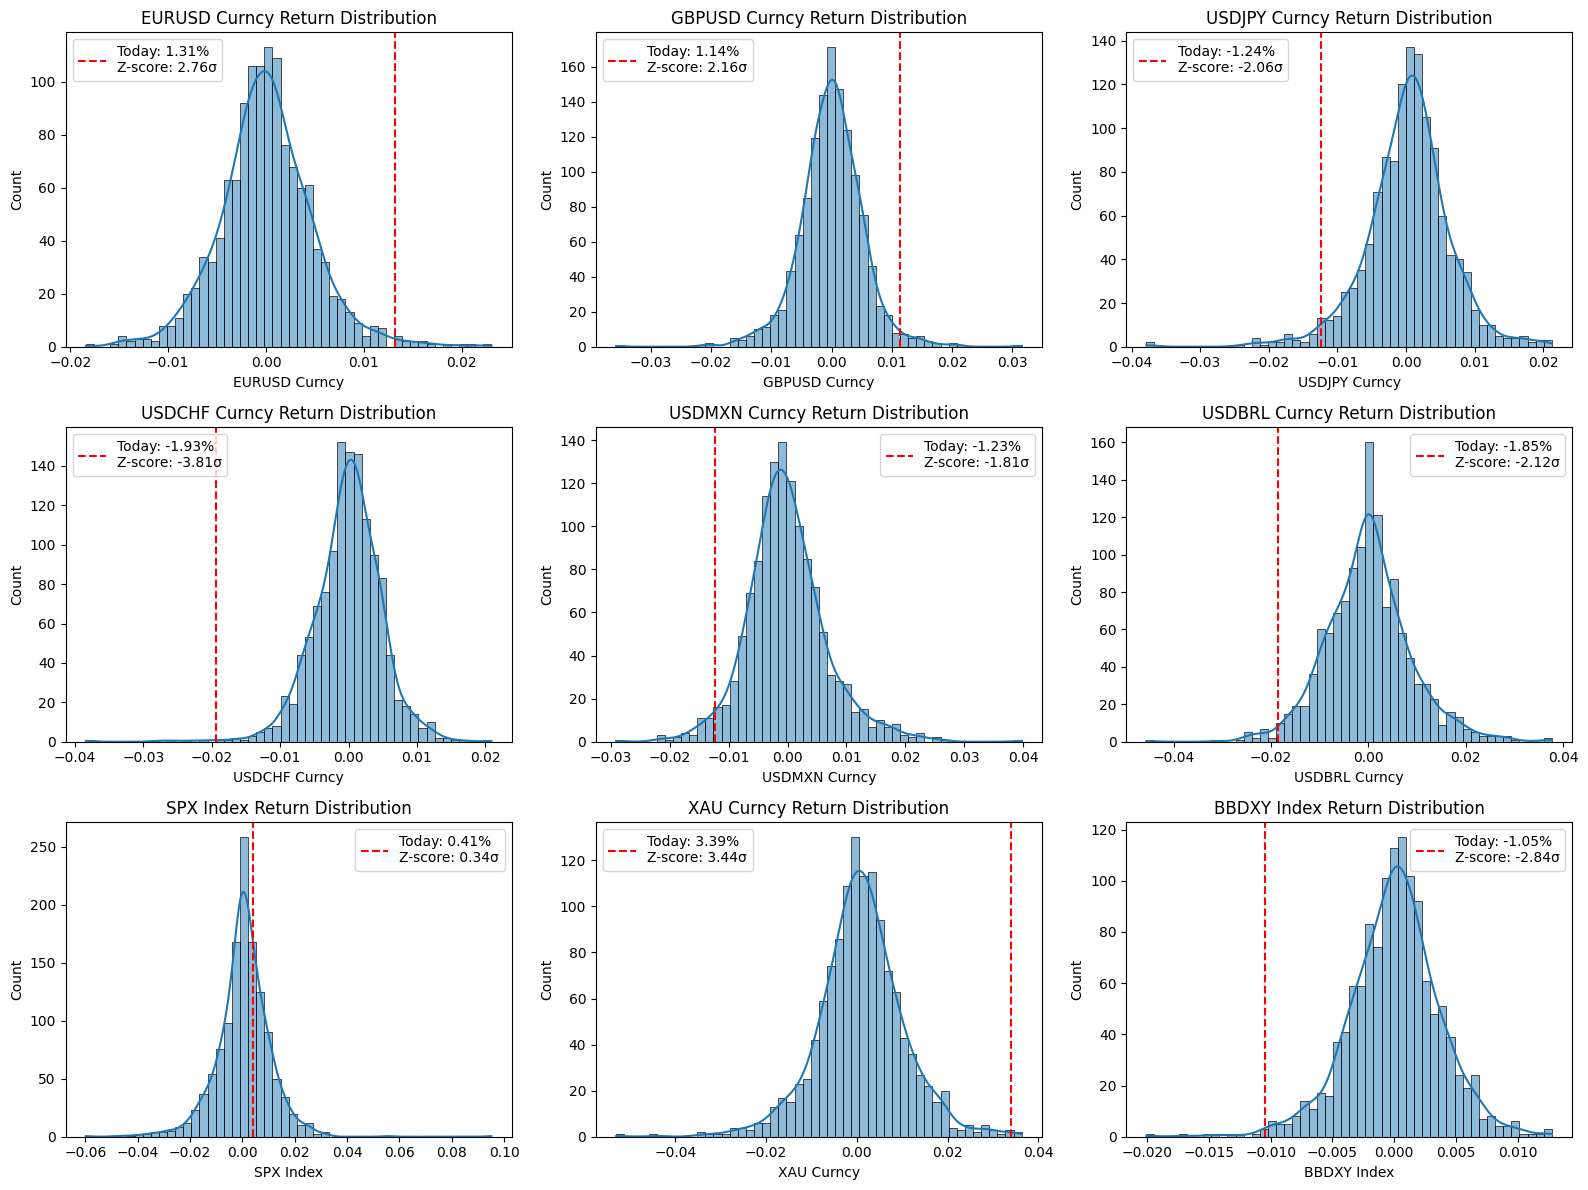

In [11]:
returns = df.pct_change().dropna()


latest_returns = returns.iloc[-1]

num_assets = len(returns.columns)
n_cols = 3
n_rows = int(np.ceil(len(returns.columns) / n_cols))
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()  # make it easy to index

if num_assets == 1:
    axes = [axes]  # Make it iterable if only one asset

for i, col in enumerate(returns.columns):
    ax = axes[i]

    mean = returns[col].mean()
    std = returns[col].std()
    today = latest_returns[col]
    zscore = (today - mean) / std

    sns.histplot(returns[col], bins=50, kde=True, ax=ax)
    axes[i].axvline(today, color='red', linestyle='--',
                label=f"Today: {today:.2%}\nZ-score: {zscore:.2f}σ")
    axes[i].set_title(f"{col} Return Distribution")
    axes[i].legend()

plt.tight_layout()
plt.show()

In [6]:
df

,EURUSD,GBPUSD,USDJPY,USDCHF,USDMXN,USDBRL
2015-04-13,1.0567,1.4676,120.13,0.9780,15.3827,3.1212
2015-04-14,1.0655,1.4782,119.40,0.9723,15.2635,3.0634
2015-04-15,1.0684,1.4842,119.14,0.9645,15.2744,3.0287
2015-04-16,1.0761,1.4934,119.02,0.9560,15.1724,3.0205
2015-04-17,1.0806,1.4962,118.90,0.9521,15.3356,3.0408
...,...,...,...,...,...,...
2025-04-04,1.0956,1.2887,146.93,0.8608,20.4441,5.8423
2025-04-07,1.0912,1.2724,147.84,0.8593,20.6954,5.9144
2025-04-08,1.0958,1.2765,146.27,0.8478,20.8473,6.0118
2025-04-09,1.0949,1.2820,147.76,0.8570,20.2415,5.8252


In [2]:
def Daily_GetTopCCYs(currency_pairs, years):
    df_ccy = {}
    start_date = (datetime.today() - timedelta(days=(years * 365))).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')

    for ticker in currency_pairs:
        data_ccy = blp.bdh(
            tickers=f"{ticker}" ,
            flds=["PX_LAST"],  # Adjust fields as needed
            start_date=start_date,
            end_date=end_date,
            Per="D"  # Daily data
        )
        data_ccy.columns = [ticker]
        df_ccy[ticker] = data_ccy
    df_ccyAll = pd.concat(df_ccy, axis=1)
    df_ccyAll.columns = df_ccyAll.columns.droplevel(0) if isinstance(df_ccyAll.columns, pd.MultiIndex) else df_ccyAll.columns
    df_ccyAll = df_ccyAll.sort_index(ascending=True)
    return df_ccyAll




,DXY Curncy
2005-10-27,89.100
2005-10-28,89.590
2005-10-31,90.070
2005-11-01,90.080
2005-11-02,89.720
...,...
2025-10-16,98.336
2025-10-17,98.433
2025-10-20,98.586
2025-10-21,98.934


In [41]:
df_dxy = Daily_GetTopCCYs(['DXY Curncy'], 20)
df_dxy


def calculate_inside_1std(window):
    if len(window) < 2:
        return np.nan
    mean = window.mean()
    std = window.std()
    lower_bound = mean - std
    upper_bound = mean + std
    inside = ((window >= lower_bound) & (window <= upper_bound)).sum()
    return (inside / len(window)) * 100

df_dxy.index = pd.to_datetime(df_dxy.index)
df_dxy = df_dxy.sort_index()

window_size = 90

# Calculate rolling statistics and store them in the dataframe
df_dxy['rolling_mean'] = df_dxy['DXY Curncy'].rolling(
    window=window_size, 
    min_periods=window_size
).mean()

df_dxy['rolling_std'] = df_dxy['DXY Curncy'].rolling(
    window=window_size, 
    min_periods=window_size
).std()

# Calculate bounds based on rolling statistics
df_dxy['upper_1std'] = df_dxy['rolling_mean'] + df_dxy['rolling_std']
df_dxy['lower_1std'] = df_dxy['rolling_mean'] - df_dxy['rolling_std']
df_dxy['upper_2std'] = df_dxy['rolling_mean'] + (2 * df_dxy['rolling_std'])
df_dxy['lower_2std'] = df_dxy['rolling_mean'] - (2 * df_dxy['rolling_std'])

# Calculate percentage inside 1std
df_dxy['pct_inside_1std'] = df_dxy['DXY Curncy'].rolling(
    window=window_size,
    min_periods=window_size
).apply(calculate_inside_1std)

# Optional: Calculate z-score for each day relative to its rolling window
df_dxy['z_score'] = (df_dxy['DXY Curncy'] - df_dxy['rolling_mean']) / df_dxy['rolling_std']

# Optional: Add a column indicating if current value is inside/outside bounds
df_dxy['inside_1std'] = (
    (df_dxy['DXY Curncy'] >= df_dxy['lower_1std']) & 
    (df_dxy['DXY Curncy'] <= df_dxy['upper_1std'])
)

# Display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)


df_dxy.tail(10)

,DXY Curncy,rolling_mean,rolling_std,upper_1std,lower_1std,upper_2std,lower_2std,pct_inside_1std,z_score,inside_1std
2025-10-09,99.538,98.054033,0.670826,98.724859,97.383207,99.395685,96.712381,67.777778,2.212148,False
2025-10-10,98.978,98.051678,0.667155,98.718832,97.384523,99.385987,96.717369,67.777778,1.388467,False
2025-10-13,99.269,98.055344,0.672968,98.728312,97.382377,99.401280,96.709409,67.777778,1.803438,False
2025-10-14,99.047,98.054778,0.672101,98.726878,97.382677,99.398979,96.710577,67.777778,1.476300,False
2025-10-15,98.793,98.056578,0.673876,98.730454,97.382702,99.404329,96.708826,66.666667,1.092816,False
2025-10-16,98.336,98.061189,0.674357,98.735546,97.386832,99.409904,96.712474,67.777778,0.407516,True
2025-10-17,98.433,98.063956,0.675377,98.739332,97.388579,99.414709,96.713202,67.777778,0.546427,True
2025-10-20,98.586,98.070489,0.677572,98.748061,97.392917,99.425633,96.715345,66.666667,0.760821,True
2025-10-21,98.934,98.071756,0.679094,98.750849,97.392662,99.429943,96.713568,66.666667,1.269698,False
2025-10-22,98.810,98.070700,0.677857,98.748557,97.392843,99.426414,96.714986,66.666667,1.090643,False


C:\Users\ntaylor\AppData\Local\Temp\ipykernel_55040\1679900768.py:51: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = pd.date_range(start='2006', end='2025', freq='3Y')


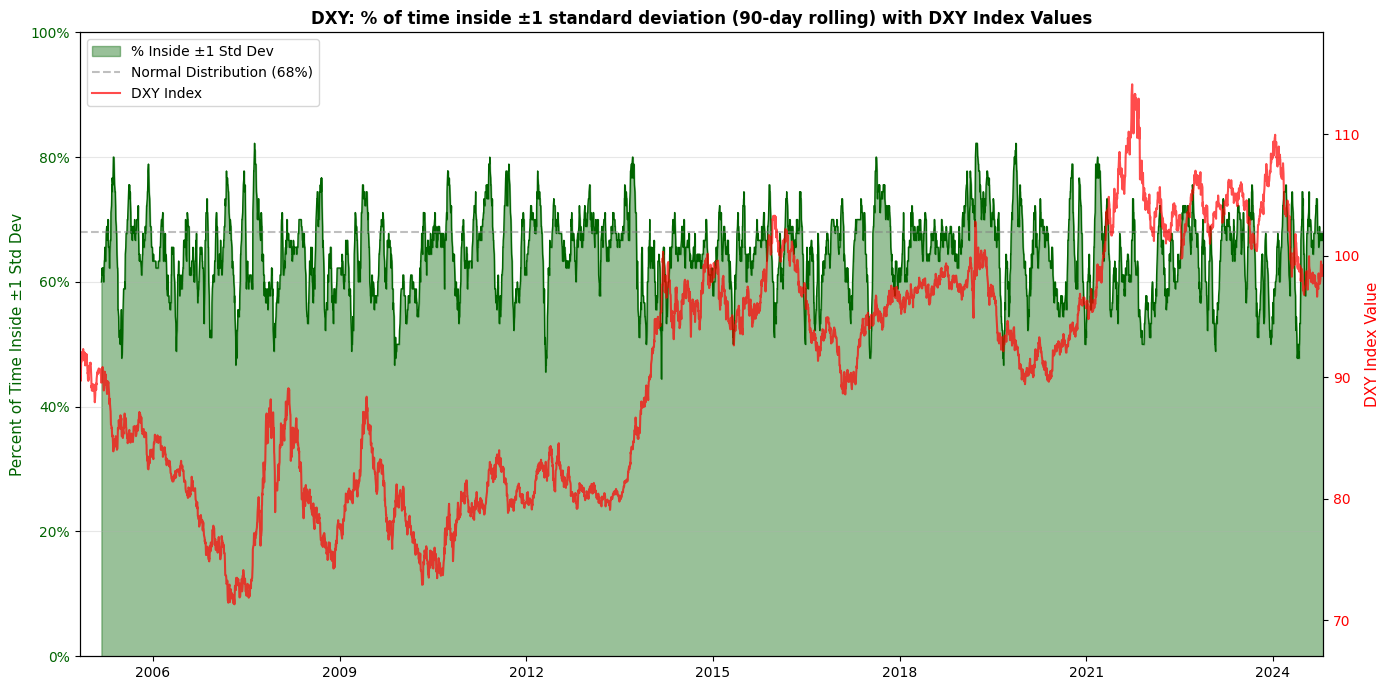

Current % inside 1 std: 66.7%
Current DXY level: 98.81
Average % inside: 64.7%
Max % inside: 82.2%
Min % inside: 44.4%

Note: Normal distribution expects ~68% inside ±1 std dev


In [42]:
df_dxy = Daily_GetTopCCYs(['DXY Curncy'], 20)
df_dxy

def calculate_inside_1std(window):
    if len(window) < 2:
        return np.nan
    mean = window.mean()
    std = window.std()
    lower_bound = mean - std
    upper_bound = mean + std
    inside = ((window >= lower_bound) & (window <= upper_bound)).sum()
    return (inside / len(window)) * 100

df_dxy.index = pd.to_datetime(df_dxy.index)
df_dxy = df_dxy.sort_index()

window_size = 90
df_dxy['pct_inside_1std'] = df_dxy['DXY Curncy'].rolling(
    window=window_size, 
    min_periods=window_size
).apply(calculate_inside_1std)

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.fill_between(df_dxy.index, 0, df_dxy['pct_inside_1std'], 
                 color='darkgreen', alpha=0.4, label='% Inside ±1 Std Dev')
ax1.plot(df_dxy.index, df_dxy['pct_inside_1std'], 
        color='darkgreen', linewidth=1)
ax1.set_ylim(0, 100)
ax1.set_xlim(df_dxy.index[0], df_dxy.index[-1])
ax1.set_ylabel('Percent of Time Inside ±1 Std Dev', fontsize=11, color='darkgreen')
ax1.set_title('DXY: % of time inside ±1 standard deviation (90-day rolling) with DXY Index Values', 
             fontsize=12, fontweight='bold')
ax1.set_yticks([0, 20, 40, 60, 80, 100])
ax1.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax1.tick_params(axis='y', labelcolor='darkgreen')

# Add horizontal line at 68% (expected value for normal distribution)
ax1.axhline(y=68, color='gray', linestyle='--', alpha=0.5, label='Normal Distribution (68%)')

ax2 = ax1.twinx()
ax2.plot(df_dxy.index, df_dxy['DXY Curncy'], 
         color='red', linewidth=1.5, alpha=0.7, label='DXY Index')
ax2.set_ylabel('DXY Index Value', fontsize=11, color='red')
ax2.tick_params(axis='y', labelcolor='red')
dxy_min = df_dxy['DXY Curncy'].min()
dxy_max = df_dxy['DXY Curncy'].max()
margin = (dxy_max - dxy_min) * 0.1
ax2.set_ylim(dxy_min - margin, dxy_max + margin)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_facecolor('white')
years = pd.date_range(start='2006', end='2025', freq='3Y')
ax1.set_xticks(years)
ax1.set_xticklabels([year.year for year in years])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Current % inside 1 std: {df_dxy['pct_inside_1std'].iloc[-1]:.1f}%")
print(f"Current DXY level: {df_dxy['DXY Curncy'].iloc[-1]:.2f}")
print(f"Average % inside: {df_dxy['pct_inside_1std'].mean():.1f}%")
print(f"Max % inside: {df_dxy['pct_inside_1std'].max():.1f}%")
print(f"Min % inside: {df_dxy['pct_inside_1std'].min():.1f}%")
print(f"\nNote: Normal distribution expects ~68% inside ±1 std dev")

In [43]:
df_dxy = Daily_GetTopCCYs(['DXY Curncy'], 20)
df_dxy

last_90_days = df_dxy['DXY Curncy'].tail(90)

# Calculate statistics for the current 90-day window
current_mean = last_90_days.mean()
current_std = last_90_days.std()
current_min = last_90_days.min()
current_max = last_90_days.max()
current_median = last_90_days.median()

# Calculate the bounds
upper_1std = current_mean + current_std
lower_1std = current_mean - current_std
upper_2std = current_mean + (2 * current_std)
lower_2std = current_mean - (2 * current_std)

# Current spot level
current_spot = df_dxy['DXY Curncy'].iloc[-1]

# Calculate where current spot is relative to the distribution
z_score = (current_spot - current_mean) / current_std

# Count how many observations are outside bounds in current window
outside_1std = ((last_90_days < lower_1std) | (last_90_days > upper_1std)).sum()
inside_1std = ((last_90_days >= lower_1std) & (last_90_days <= upper_1std)).sum()

# Print detailed statistics
print("=" * 60)
print("CURRENT 90-DAY WINDOW STATISTICS")
print("=" * 60)
print(f"Period: {last_90_days.index[0].strftime('%Y-%m-%d')} to {last_90_days.index[-1].strftime('%Y-%m-%d')}")
print(f"Number of observations: {len(last_90_days)}")
print()
print("DXY LEVELS:")
print(f"  Current Spot:          {current_spot:.2f}")
print(f"  90-day Mean:           {current_mean:.2f}")
print(f"  90-day Median:         {current_median:.2f}")
print(f"  90-day Std Dev:        {current_std:.2f}")
print()
print("STATISTICAL BOUNDS:")
print(f"  -2 Std Dev:            {lower_2std:.2f}")
print(f"  -1 Std Dev:            {lower_1std:.2f}")
print(f"  Mean:                  {current_mean:.2f}")
print(f"  +1 Std Dev:            {upper_1std:.2f}")
print(f"  +2 Std Dev:            {upper_2std:.2f}")
print()
print("RANGE STATISTICS:")
print(f"  90-day Min:            {current_min:.2f}")
print(f"  90-day Max:            {current_max:.2f}")
print(f"  90-day Range:          {current_max - current_min:.2f}")
print()
print("CURRENT POSITIONING:")
print(f"  Z-Score:               {z_score:.2f}")
if z_score > 0:
    print(f"  Position:              {z_score:.2f} std devs ABOVE mean")
else:
    print(f"  Position:              {abs(z_score):.2f} std devs BELOW mean")
print()
print("DISTRIBUTION ANALYSIS:")
print(f"  Days inside ±1σ:       {inside_1std} ({inside_1std/90*100:.1f}%)")
print(f"  Days outside ±1σ:      {outside_1std} ({outside_1std/90*100:.1f}%)")
print(f"  Expected (normal):     61 (68%)")
print("=" * 60)

CURRENT 90-DAY WINDOW STATISTICS
Period: 2025-06-19 to 2025-10-22
Number of observations: 90

DXY LEVELS:
  Current Spot:          98.81
  90-day Mean:           98.07
  90-day Median:         98.09
  90-day Std Dev:        0.68

STATISTICAL BOUNDS:
  -2 Std Dev:            96.71
  -1 Std Dev:            97.39
  Mean:                  98.07
  +1 Std Dev:            98.75
  +2 Std Dev:            99.43

RANGE STATISTICS:
  90-day Min:            96.63
  90-day Max:            99.97
  90-day Range:          3.34

CURRENT POSITIONING:
  Z-Score:               1.09
  Position:              1.09 std devs ABOVE mean

DISTRIBUTION ANALYSIS:
  Days inside ±1σ:       60 (66.7%)
  Days outside ±1σ:      30 (33.3%)
  Expected (normal):     61 (68%)


In [46]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import table
from PIL import Image

from xbbg import blp
from datetime import datetime, timedelta
from typing import List, Optional, Tuple, Dict
from itertools import permutations

from itertools import product
from scipy.stats import percentileofscore, gaussian_kde, norm
from scipy.stats import zscore
import math
from itertools import combinations
import time
from sklearn.linear_model import LinearRegression







def ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(currency_list, tenors, lookback_days=252):
    def xCCY_AllPairs_MultiTenor_Analysis(currency_list: List[str], tenor_list: List[str]):
        end_date = datetime.now().strftime("%Y-%m-%d")
        start_date = (datetime.now() - timedelta(days=365*6)).strftime("%Y-%m-%d")
        base_ccy = sorted(set(currency_list))  # These are currency pairs like EURUSD, GBPUSD, etc.
        results_by_tenor: Dict[str, pd.DataFrame] = {}
        currency_avg_metrics: Dict[str, pd.DataFrame] = {}
        correlation_data: Dict[str, pd.DataFrame] = {}  # Store correlation data for each tenor
        df_all_by_tenor: Dict[str, pd.DataFrame] = {}  # Store df_all for each tenor for beta calculations
        for tenor in tenor_list:
            data_dict: Dict[str, pd.Series] = {}
            for ccy_pair in base_ccy:  # ccy_pair is like 'EURUSD'
                ticker_IV = f"{ccy_pair}V{tenor} BGN Curncy"
                try:
                    data_IV = blp.bdh(
                        tickers=ticker_IV,
                        flds="PX_LAST",
                        start_date=start_date,
                        end_date=end_date)
                    data_IV.columns = data_IV.columns.get_level_values(1)
                    data_dict[ccy_pair] = data_IV['PX_LAST']
                except Exception as e:
                    continue
            if not data_dict:
                continue
            df_all = pd.DataFrame(data_dict).dropna()
            if df_all.empty:
                continue
            df_all_by_tenor[tenor] = df_all
            # correlation_matrix = df_all.corr()
            correlation_matrix = df_all.diff().dropna().corr()
            correlation_data[tenor] = correlation_matrix
            latest_date = df_all.index[-1]
            currency_pairs = list(permutations(base_ccy, 2))  # All combinations of currency pairs
            pair_results = []
            currency_volatilities: Dict[str, List[Dict[str, float]]] = {ccy_pair: [] for ccy_pair in base_ccy}
            for ccy_pair1, ccy_pair2 in currency_pairs:  # e.g., ('EURUSD', 'USDJPY')
                if ccy_pair1 not in df_all.columns or ccy_pair2 not in df_all.columns:
                    continue
                current_spread = df_all.loc[latest_date, ccy_pair1] - df_all.loc[latest_date, ccy_pair2]
                historical_spreads = df_all[ccy_pair1] - df_all[ccy_pair2]
                three_months_ago = latest_date - timedelta(days=30)
                one_year_ago    = latest_date - timedelta(days=90)
                three_years_ago = latest_date - timedelta(days=365*3)
                five_years_ago  = latest_date - timedelta(days=365*5)
                past_3_months_spreads = historical_spreads.loc[historical_spreads.index >= three_months_ago]
                past_year_spreads     = historical_spreads.loc[historical_spreads.index >= one_year_ago]
                past_3_years_spreads  = historical_spreads.loc[historical_spreads.index >= three_years_ago]
                past_5_years_spreads  = historical_spreads.loc[historical_spreads.index >= five_years_ago]
                if len(past_5_years_spreads) < 2:
                    continue
                percentile_3_months = percentileofscore(past_3_months_spreads, current_spread)
                percentile_1_year   = percentileofscore(past_year_spreads,     current_spread)
                percentile_3_years  = percentileofscore(past_3_years_spreads,  current_spread) if len(past_3_years_spreads) > 1 else None
                percentile_5_years  = percentileofscore(past_5_years_spreads,  current_spread) if len(past_5_years_spreads) > 1 else None
                spread_volatility_3m = past_3_months_spreads.std()
                spread_volatility_1y = past_year_spreads.std()
                spread_volatility_3y = past_3_years_spreads.std() if len(past_3_years_spreads) > 1 else None
                spread_volatility_5y = past_5_years_spreads.std() if len(past_5_years_spreads) > 1 else None
                mean_spread_3m = past_3_months_spreads.mean()
                mean_spread_1y = past_year_spreads.mean()
                mean_spread_3y = past_3_years_spreads.mean() if len(past_3_years_spreads) > 1 else None
                mean_spread_5y = past_5_years_spreads.mean() if len(past_5_years_spreads) > 1 else None
                relative_position_3m = abs(current_spread - mean_spread_3m) / spread_volatility_3m if spread_volatility_3m and spread_volatility_3m > 0 else 0
                relative_position_1y = abs(current_spread - mean_spread_1y) / spread_volatility_1y if spread_volatility_1y and spread_volatility_1y > 0 else 0
                relative_position_3y = (abs(current_spread - mean_spread_3y) / spread_volatility_3y
                                        if (spread_volatility_3y and spread_volatility_3y > 0 and mean_spread_3y is not None) else None)
                relative_position_5y = (abs(current_spread - mean_spread_5y) / spread_volatility_5y
                                        if (spread_volatility_5y and spread_volatility_5y > 0 and mean_spread_5y is not None) else None)
                correlation = correlation_matrix.loc[ccy_pair1, ccy_pair2] if (ccy_pair1 in correlation_matrix.index and ccy_pair2 in correlation_matrix.columns) else None
                pair_result = {
                    'Tenor': tenor,
                    'Pair': f"{ccy_pair1}-{ccy_pair2}",
                    'CCY1': ccy_pair1,  # Now this is a currency pair like 'EURUSD'
                    'CCY2': ccy_pair2,  # Now this is a currency pair like 'USDJPY'
                    'Correlation': round(correlation, 4) if correlation is not None else None,
                    'Current_Spread': round(current_spread, 4),
                    'Spread_Mean_3M': round(mean_spread_3m, 4) if mean_spread_3m is not None else None,
                    'Spread_Mean_1Y': round(mean_spread_1y, 4) if mean_spread_1y is not None else None,
                    'Spread_Mean_3Y': round(mean_spread_3y, 4) if mean_spread_3y is not None else None,
                    'Spread_Mean_5Y': round(mean_spread_5y, 4) if mean_spread_5y is not None else None,
                    'Spread_STD_3M': round(spread_volatility_3m, 4) if spread_volatility_3m is not None else None,
                    'Spread_STD_1Y': round(spread_volatility_1y, 4) if spread_volatility_1y is not None else None,
                    'Spread_STD_3Y': round(spread_volatility_3y, 4) if spread_volatility_3y is not None else None,
                    'Spread_STD_5Y': round(spread_volatility_5y, 4) if spread_volatility_5y is not None else None,
                    'Spread_ZScore_3M': round(relative_position_3m, 4) if relative_position_3m is not None else None,
                    'Spread_ZScore_1Y': round(relative_position_1y, 4) if relative_position_1y is not None else None,
                    'Spread_ZScore_3Y': round(relative_position_3y, 4) if relative_position_3y is not None else None,
                    'Spread_ZScore_5Y': round(relative_position_5y, 4) if relative_position_5y is not None else None,
                    'Percentile_1M': round(percentile_3_months, 3) if percentile_3_months is not None else None,
                    'Percentile_3M': round(percentile_1_year, 3) if percentile_1_year is not None else None,
                    'Percentile_3Y': round(percentile_3_years, 3) if percentile_3_years is not None else None,
                    'Percentile_5Y': round(percentile_5_years, 3) if percentile_5_years is not None else None}
                pair_results.append(pair_result)
                if spread_volatility_1y is not None and relative_position_1y is not None:
                    currency_volatilities[ccy_pair1].append({
                        'Spread_STD_1y': spread_volatility_1y,
                        'Spread_ZScore_1y': relative_position_1y,
                        'pair': f"{ccy_pair1}-{ccy_pair2}"})
            results_by_tenor[tenor] = pd.DataFrame(pair_results)
            tenor_currency_averages = []
            for ccy_pair in base_ccy:
                if currency_volatilities[ccy_pair]:
                    avg_spread_vol = np.mean([x['Spread_STD_1y'] for x in currency_volatilities[ccy_pair]])
                    avg_relative_pos = np.mean([x['Spread_ZScore_1y'] for x in currency_volatilities[ccy_pair]])
                    num_pairs = len(currency_volatilities[ccy_pair])
                    tenor_currency_averages.append({
                        'Currency': ccy_pair,  # Now this is a currency pair like 'EURUSD'
                        'Tenor': tenor,
                        'Avg_Spread_STD_1Y': round(avg_spread_vol, 4),
                        'Avg_Spread_ZScore_1Y': round(avg_relative_pos, 4),
                        'Num_Pairs': num_pairs})
            currency_avg_metrics[tenor] = pd.DataFrame(tenor_currency_averages).sort_values('Avg_Spread_STD_1Y')
        return results_by_tenor, currency_avg_metrics, correlation_data, df_all_by_tenor
    
    # ----------------------------- Averaging Spreads -----------------------------
    # ------ Finding Averages of Each Pair Spread (Pair - CCY_Other) for Each Tenor ------
    def find_ave_allCCYallLookback_equalWeights(results_by_tenor, tenors):
        tenor_results = {}  
        for tenor in tenors:
            if tenor in results_by_tenor:
                df = results_by_tenor[tenor]
                all_currency_pairs = set(df['CCY1'].tolist() + df['CCY2'].tolist())
                currency_percentile_summary = []
                for ccy_pair in all_currency_pairs:  # ccy_pair is like 'EURUSD'
                    ccy_pairs = df[df['CCY1'] == ccy_pair]  # All pairs where EURUSD is first
                    if len(ccy_pairs) > 0:
                        avg_percentile_3m = ccy_pairs['Percentile_1M'].mean()
                        avg_percentile_1y = ccy_pairs['Percentile_3M'].mean()
                        percentile_3y_values = ccy_pairs['Percentile_3Y'].dropna()
                        percentile_5y_values = ccy_pairs['Percentile_5Y'].dropna()
                        avg_percentile_3y = percentile_3y_values.mean() if len(percentile_3y_values) > 0 else None
                        avg_percentile_5y = percentile_5y_values.mean() if len(percentile_5y_values) > 0 else None
                        currency_percentile_summary.append({
                            'Currency_Pair': ccy_pair,  # Updated column name for clarity
                            'Tenor': tenor,
                            'Avg_EquWeight_3M%': round(avg_percentile_3m, 3),
                            'Avg_EquWeight_1Y%': round(avg_percentile_1y, 3),
                            'Avg_EquWeight_3Y%': round(avg_percentile_3y, 3) if avg_percentile_3y is not None else None,
                            'Avg_EquWeight_5Y%': round(avg_percentile_5y, 3) if avg_percentile_5y is not None else None,
                            'Num_Pairs': len(ccy_pairs)})
                percentile_df = pd.DataFrame(currency_percentile_summary).sort_values('Avg_EquWeight_5Y%')
                tenor_results[tenor] = percentile_df
        return tenor_results
    
    # ------  Correlation-Weighted Averaging Function ------
    def find_ave_allCCYallLookback_correlationWeights(results_by_tenor, tenors):
        tenor_results = {}  
        for tenor in tenors:
            if tenor in results_by_tenor:
                df = results_by_tenor[tenor]
                all_currency_pairs = set(df['CCY1'].tolist() + df['CCY2'].tolist())
                currency_percentile_summary = []
                for ccy_pair in all_currency_pairs:  # ccy_pair is like 'EURUSD'
                    ccy_pairs = df[df['CCY1'] == ccy_pair].copy()  # All pairs where EURUSD is first
                    if len(ccy_pairs) > 0:
                        ccy_pairs_valid = ccy_pairs.dropna(subset=['Correlation'])
                        if len(ccy_pairs_valid) == 0:
                            weights = np.ones(len(ccy_pairs)) / len(ccy_pairs)
                            ccy_pairs_for_calc = ccy_pairs
                        else:
                            correlation_weights = ccy_pairs_valid['Correlation'].abs()  # Use absolute correlation
                            weights = correlation_weights / correlation_weights.sum()  # Normalize to sum to 1
                            ccy_pairs_for_calc = ccy_pairs_valid
                        weighted_avg_percentile_3m = np.average(ccy_pairs_for_calc['Percentile_1M'], weights=weights)
                        weighted_avg_percentile_1y = np.average(ccy_pairs_for_calc['Percentile_3M'], weights=weights)
                        percentile_3y_valid = ccy_pairs_for_calc['Percentile_3Y'].dropna()
                        percentile_5y_valid = ccy_pairs_for_calc['Percentile_5Y'].dropna()
                        weighted_avg_percentile_3y = None
                        weighted_avg_percentile_5y = None
                        if len(percentile_3y_valid) > 0:
                            valid_3y_indices = ccy_pairs_for_calc['Percentile_3Y'].dropna().index
                            weights_3y = weights[ccy_pairs_for_calc.index.isin(valid_3y_indices)]
                            weights_3y = weights_3y / weights_3y.sum()  # Renormalize
                            weighted_avg_percentile_3y = np.average(percentile_3y_valid, weights=weights_3y)
                        if len(percentile_5y_valid) > 0:
                            # Get weights for valid 5Y data
                            valid_5y_indices = ccy_pairs_for_calc['Percentile_5Y'].dropna().index
                            weights_5y = weights[ccy_pairs_for_calc.index.isin(valid_5y_indices)]
                            weights_5y = weights_5y / weights_5y.sum()  # Renormalize
                            weighted_avg_percentile_5y = np.average(percentile_5y_valid, weights=weights_5y)
                        avg_correlation = ccy_pairs_valid['Correlation'].mean() if len(ccy_pairs_valid) > 0 else None
                        currency_percentile_summary.append({
                            'Currency_Pair': ccy_pair,  # Updated column name for clarity
                            'Tenor': tenor,
                            'Avg_CorrWeight_3M%': round(weighted_avg_percentile_3m, 3),
                            'Avg_CorrWeight_1Y%': round(weighted_avg_percentile_1y, 3),
                            'Avg_CorrWeight_3Y%': round(weighted_avg_percentile_3y, 3) if weighted_avg_percentile_3y is not None else None,
                            'Avg_CorrWeight_5Y%': round(weighted_avg_percentile_5y, 3) if weighted_avg_percentile_5y is not None else None,
                            'Num_Pairs': len(ccy_pairs)})
                percentile_df = pd.DataFrame(currency_percentile_summary).sort_values('Avg_CorrWeight_5Y%')
                tenor_results[tenor] = percentile_df
        return tenor_results
    
    # --------------------- Executing Functions ---------------------
    results_by_tenor, currency_avg_metrics, correlation_data, df_all_by_tenor = xCCY_AllPairs_MultiTenor_Analysis(
        currency_list, tenors)
    
    ave_tenorBuckets_equalBuckets = find_ave_allCCYallLookback_equalWeights(results_by_tenor, tenors)
    ave_tenorBuckets_correlationWeighted = find_ave_allCCYallLookback_correlationWeights(results_by_tenor, tenors)
    
    
    return {
        'results_by_tenor': results_by_tenor,
        'ave_results_by_tenor_equalWeights': ave_tenorBuckets_equalBuckets,
        'ave_results_by_tenor_correlationWeighted': ave_tenorBuckets_correlationWeighted,
        'correlation_data': correlation_data
    }





# -------------------------------------------------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------------------------
"""
Indvidual CCY Focus vs Rest of CCY        [(EURUSD-USDJPY)(EURUSD-GBPUSD)(EURUSD-USDCHF)...]
    - (1) Spread Percentiles
    - (2) Spread Mean
    - (3) Spread STD

    - Input: ccy_interest (ccy you want compared to rest of ccys), tenor_interest (specific tenor you want to compare spreads on)
"""
def IndivdualCCYSpread_Percentiles_TenorGrouped(ccy_interest, tenor_interest):
    currency_list_broad = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK', 'USDMXN','USDBRL', 'USDCNH']
    analysis_results = ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(currency_list_broad, tenor_interest)
    tenor = tenor_interest[0]
    data_single = analysis_results["results_by_tenor"][tenor].copy()
    df = data_single[data_single["CCY1"] == ccy_interest]
    df_clean = df[['Pair', 'Tenor', 'Correlation', 'Current_Spread', 'Percentile_1M',  'Percentile_3M',  'Percentile_3Y',  'Percentile_5Y']]
    return df_clean

def IndivdualCCYSpread_Mean_TenorGrouped(ccy_interest, tenor_interest):
    currency_list_broad = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK', 'USDMXN','USDBRL', 'USDCNH']
    analysis_results = ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(currency_list_broad, tenor_interest)
    tenor = tenor_interest[0]
    data_single = analysis_results["results_by_tenor"][tenor].copy()
    df = data_single[data_single["CCY1"] == ccy_interest]
    df_clean = df[['Pair', 'Tenor', 'Current_Spread', 'Spread_Mean_3M', 'Spread_Mean_1Y', 'Spread_Mean_3Y', 'Spread_Mean_5Y']]
    df_clean.columns = df_clean.columns.str.replace("Spread_", "")
    return df_clean
def IndivdualCCYSpread_STD_TenorGrouped(ccy_interest, tenor_interest):
    currency_list_broad = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK', 'USDMXN','USDBRL', 'USDCNH']
    analysis_results = ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(currency_list_broad, tenor_interest)
    tenor = tenor_interest[0]
    data_single = analysis_results["results_by_tenor"][tenor].copy()
    df = data_single[data_single["CCY1"] == ccy_interest]
    df_clean = df[['Pair', 'Tenor', 'Current_Spread', 'Spread_STD_3M', 'Spread_STD_1Y', 'Spread_STD_3Y', 'Spread_STD_5Y']]
    df_clean.columns = df_clean.columns.str.replace("Spread_", "")
    return df_clean


ccy_interest = 'AUDUSD'
tenor_interest = ['2M']
IndivdualCCYSpread_Percentiles_TenorGrouped(ccy_interest, tenor_interest)

,Pair,Tenor,Correlation,Current_Spread,Percentile_1M,Percentile_3M,Percentile_3Y,Percentile_5Y
0,AUDUSD-EURUSD,2M,0.6976,2.3800,82.609,93.846,30.204,24.118
1,AUDUSD-GBPUSD,2M,0.6452,1.5950,73.913,75.385,13.410,18.712
2,AUDUSD-NZDUSD,2M,0.9729,0.0150,82.609,93.077,87.931,80.905
3,AUDUSD-USDBRL,2M,0.5214,-2.9500,60.870,75.385,76.245,85.736
4,AUDUSD-USDCAD,2M,0.7092,4.5375,65.217,87.692,69.987,75.767
5,AUDUSD-USDCHF,2M,0.6856,1.2600,52.174,81.538,16.475,9.893
6,AUDUSD-USDCNH,2M,0.5690,5.9250,73.913,89.231,90.677,81.135
7,AUDUSD-USDJPY,2M,0.5935,-0.4325,86.957,93.846,49.170,30.138
8,AUDUSD-USDMXN,2M,0.6385,0.2850,95.652,98.462,87.484,86.503
9,AUDUSD-USDNOK,2M,0.7796,-0.9975,52.174,80.000,80.460,87.730


In [1]:
import pandas as pd
import numpy as np

from xbbg import blp
import pdblp
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from pandas.plotting import table
import re

from pandas.tseries.offsets import DateOffset
from scipy.stats import percentileofscore
from typing import List, Dict, Optional, Union



from scipy import stats


from typing import Optional, List, Dict
import pandas as pd
from datetime import datetime, timedelta


In [2]:

class EconomicDataManager:
    DEFAULT_FIELDS = [
        "NAME",
        "TIME", 
        "ECO_RELEASE_TIME",
        "ECO_RELEASE_DT",
        "ACTUAL_RELEASE",
        "BN_SURVEY_MEDIAN",
        "BN_SURVEY_AVERAGE", 
        "BN_SURVEY_HIGH",
        "BN_SURVEY_LOW",
        "FORECAST_STANDARD_DEVIATION",
        "BN_SURVEY_NUMBER_OBSERVATIONS"]
    FUTURE_FIELDS = ["ECO_RELEASE_DT", "ECO_RELEASE_TIME", "NAME"]
    FIELD_RENAME_MAP = {
        "ECO_RELEASE_DT": "ReleaseDate",
        "ECO_RELEASE_TIME": "ReleaseTime",
        "ACTUAL_RELEASE": "Actual", 
        "BN_SURVEY_MEDIAN": "SMed",
        "BN_SURVEY_AVERAGE": "SAve",
        "BN_SURVEY_HIGH": "SHigh",
        "BN_SURVEY_LOW": "SLow",
        "FORECAST_STANDARD_DEVIATION": "ForecastSDTv",
        "BN_SURVEY_NUMBER_OBSERVATIONS": "NumbSurvey"}
    # -------------------------------------------------------------------------------------------
    # INITIALIZING Functions
    def __init__(self, bloomberg_api, indicators_dict: Optional[Dict] = None):
        self.blp = bloomberg_api
        self.indicators = indicators_dict or {}
    def add_indicators(self, currency_code: str, indicators: List[Dict]) -> None:
        self.indicators[currency_code] = indicators
    # -------------------------------------------------------------------------------------------
    # CORE DATA Retrieving Functions
    def get_futureData(self, ticker: str, days, 
                    custom_fields: Optional[List[str]] = None) -> pd.DataFrame:
        fields = custom_fields or self.FUTURE_FIELDS
        today = datetime.today().date()
        target_date = today + timedelta(days=days)
        try:
            data = self.blp.bdh(
                tickers=ticker,
                flds=fields,
                start_date=today.strftime('%Y-%m-%d'),
                end_date=target_date.strftime('%Y-%m-%d'))
            if data.empty:
                return pd.DataFrame()
            if hasattr(data.columns, 'nlevels') and data.columns.nlevels > 1:
                data.columns = data.columns.droplevel(0)
            data = data.rename(columns=self.FIELD_RENAME_MAP)
            if 'ReleaseDate' in data.columns:
                data['ReleaseDate'] = pd.to_datetime(
                    data['ReleaseDate'].astype(str).str.split('.').str[0],
                    format='%Y%m%d',
                    errors='coerce')
                data = data.dropna(subset=['ReleaseDate'])
                data = data[data['ReleaseDate'].dt.date < target_date]
                data = data.sort_values('ReleaseDate')
            return data
        except Exception as e:
            print(f"Error getting future data for {ticker}: {str(e)}")
            return pd.DataFrame()
    
    def get_pastData(self, ticker: str, days: int, 
                    custom_fields: Optional[List[str]] = None) -> pd.DataFrame:
        # For past data, we can try to get all fields
        fields = custom_fields or self.DEFAULT_FIELDS
        today = datetime.today().date()
        cutoff_date = today - timedelta(days=days)
        
        try:
            data = self.blp.bdh(
                tickers=ticker,
                flds=fields,
                start_date=(today - timedelta(days=days*2)).strftime('%Y-%m-%d'),
                end_date=today.strftime('%Y-%m-%d'))
            
            if data.empty:
                return pd.DataFrame()
            
            # Handle multi-level columns if they exist
            if hasattr(data.columns, 'nlevels') and data.columns.nlevels > 1:
                data.columns = data.columns.droplevel(0)
            
            # Rename columns using the map
            data = data.rename(columns=self.FIELD_RENAME_MAP)
            
            # Process release date if it exists
            if 'ReleaseDate' in data.columns:
                data['ReleaseDate'] = pd.to_datetime(
                    data['ReleaseDate'].astype(str).str.split('.').str[0],
                    format='%Y%m%d',
                    errors='coerce')
                data = data.dropna(subset=['ReleaseDate'])
                data = data[data['ReleaseDate'].dt.date > cutoff_date]
                data = data.sort_values('ReleaseDate')
            
            return data
            
        except Exception as e:
            print(f"Error getting past data for {ticker}: {str(e)}")
            return pd.DataFrame()
        

manager = EconomicDataManager(blp)

In [6]:
ticker = 'NFP TCH  Index'
days = 365 * 10
data = manager.get_pastData( ticker, days)

In [ ]:
data

,ReleaseDate,Actual,SMed,SAve,SHigh,SLow,ForecastSDTv,NumbSurvey
2006-03-31,2006-04-07,211.0,190.0,194.0,300.0,150.0,25.0,77.0
2006-04-30,2006-05-05,138.0,200.0,202.0,250.0,165.0,19.0,74.0
2006-05-31,2006-06-02,75.0,170.0,171.0,250.0,125.0,22.0,80.0
2006-06-30,2006-07-07,121.0,175.0,178.0,300.0,55.0,41.0,79.0
2006-07-31,2006-08-04,113.0,141.0,142.0,225.0,71.0,29.0,78.0
...,...,...,...,...,...,...,...,...
2025-10-31,2025-12-16,-105.0,-25.0,-15.0,93.0,-100.0,51.0,50.0
2025-11-30,2025-12-16,64.0,50.0,52.0,130.0,-20.0,30.0,80.0
2025-12-31,2026-01-09,50.0,70.0,70.0,155.0,23.0,26.0,71.0
2026-01-31,2026-02-11,130.0,65.0,65.0,135.0,-10.0,26.0,80.0


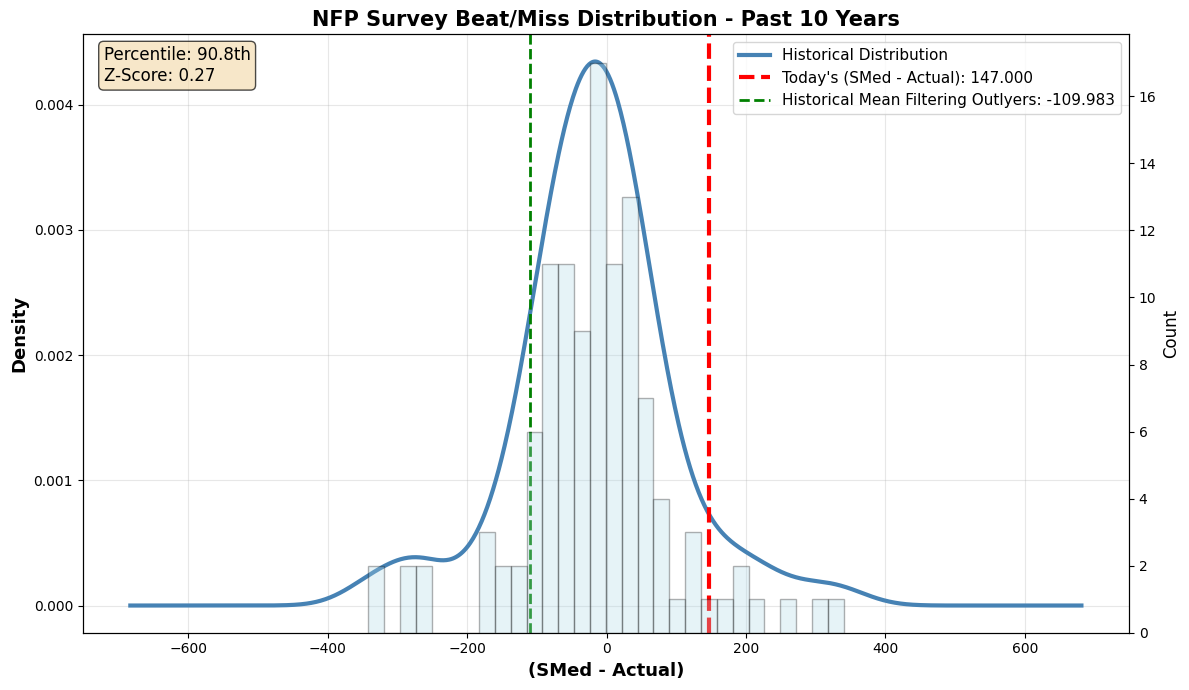

In [11]:
Q1 = data['Diff'].quantile(0.25)
Q3 = data['Diff'].quantile(0.75)
IQR = Q3 - Q1
multiplier = 3  # adjust this to be more/less aggressive
filtered_diff = data['Diff'][(data['Diff'] >= Q1 - multiplier * IQR) & 
                              (data['Diff'] <= Q3 + multiplier * IQR)]

# Recalculate stats on full data (not filtered), just filter for display
todays_diff = data['Diff'].iloc[-1]
mean_diff = data['Diff'].mean()
percentile = (data['Diff'] < todays_diff).sum() / len(data['Diff']) * 100
zscore = (todays_diff - mean_diff) / data['Diff'].std()

fig, ax = plt.subplots(figsize=(12, 7))
filtered_diff.plot(kind='kde', ax=ax, linewidth=3, color='steelblue', label='Historical Distribution')
ax2 = ax.twinx()
ax2.hist(filtered_diff, bins=30, alpha=0.3, color='lightblue', edgecolor='black')
ax2.set_ylabel('Count', fontsize=12)

ax.axvline(todays_diff, color='red', linestyle='--', linewidth=3,
           label=f"Today's (SMed - Actual): {todays_diff:.3f}", zorder=5)
ax.axvline(mean_diff, color='green', linestyle='--', linewidth=2,
           label=f'Historical Mean Filtering Outlyers: {mean_diff:.3f}')

ax.text(0.02, 0.98, f"Percentile: {percentile:.1f}th\nZ-Score: {zscore:.2f}",
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax.set_xlabel('(SMed - Actual)', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_title('NFP Survey Beat/Miss Distribution - Past 10 Years',
             fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()